In [73]:
from qiskit import transpile, QuantumCircuit
from qiskit.transpiler import CouplingMap
from qiskit.converters import circuit_to_dag
from matplotlib.patches import Rectangle
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt
import re

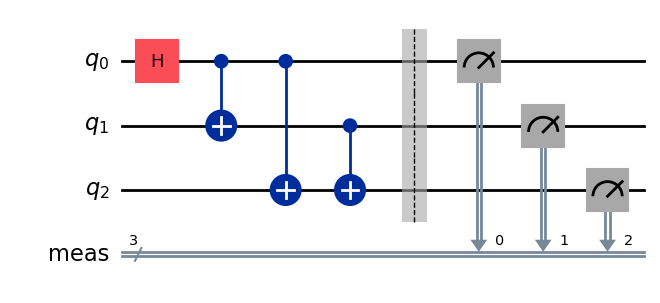

In [74]:

# Build computation as a named block
compute = QuantumCircuit(3, name="Gate computation")
compute.h(0)
compute.cx(0, 1)
compute.cx(0, 2)
compute.cx(1, 2)
compute.measure_all()
compute.draw("mpl", fold=50)


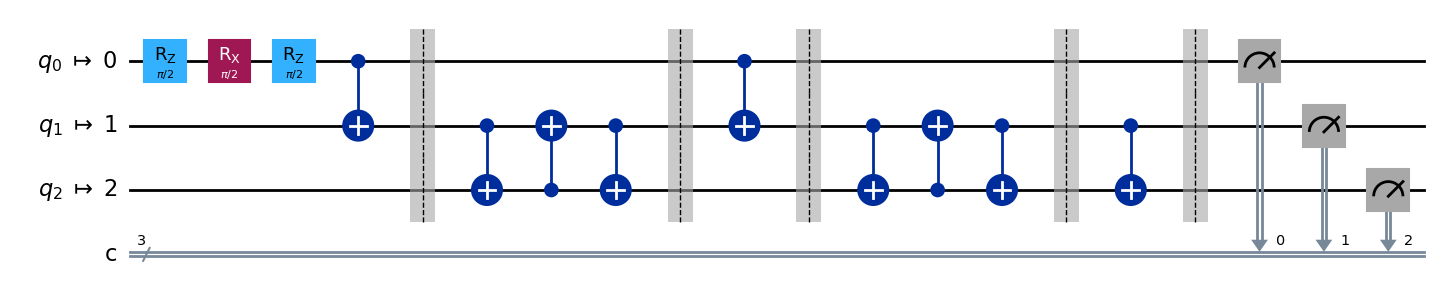

In [75]:
## Compact Circuit

# 3-qubit hardware with limited connectivity: 0 <-> 1 <-> 2
coupling_map = CouplingMap([[0, 1], [1, 0], [1, 2], [2, 1]])

# Native gate set for compilation
basis_gates = ["rz", "rx", "cx", "measure"]

# Force an explicit SWAP-back after routing CX(0,2)
force_second_swap = True

qc_for_compile = QuantumCircuit(3, 3)

# Replace H with Rx/Rz decomposition: H ≡ Rz(pi/2) -> Rx(pi/2) -> Rz(pi/2)
qc_for_compile.rz(np.pi / 2, 0)
qc_for_compile.rx(np.pi / 2, 0)
qc_for_compile.rz(np.pi / 2, 0)

# Original logical first gate
qc_for_compile.cx(0, 1)

if force_second_swap:
    # Manual routing for logical CX(0,2) on 0-1-2 chain, explicitly swapping back
    qc_for_compile.barrier()
    qc_for_compile.swap(1, 2)
    qc_for_compile.barrier()
    qc_for_compile.cx(0, 1)
    qc_for_compile.barrier()
    qc_for_compile.swap(1, 2)  # explicit second SWAP (swap-back)
    qc_for_compile.barrier()
    qc_for_compile.cx(1, 2)    # original logical final CX after mapping is restored
    qc_for_compile.barrier()
else:
    # Let transpiler route automatically
    qc_for_compile.cx(0, 2)
    qc_for_compile.cx(1, 2)

# Manually force measurement wiring: q[i] -> c[measurement_wiring[i]]
measurement_wiring = [0, 1, 2]
for q, c in enumerate(measurement_wiring):
    qc_for_compile.measure(q, c)

compiled_qc = transpile(
    qc_for_compile,
    basis_gates=basis_gates,
    coupling_map=coupling_map,
    optimization_level=0,
    initial_layout=[0, 1, 2],
    layout_method="trivial",
    routing_method="none" if force_second_swap else "basic",
)


compiled_qc.draw("mpl", fold=50)


## Noisy-device simulation: `compute` vs `compiled_qc`

This section simulates both circuits on the same noisy backend.
The key idea is that two-qubit gates (especially `cx`) are typically noisier, so circuits with more gates usually drift further from ideal measurement statistics.

In [76]:
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, ReadoutError, depolarizing_error


def normalize_counts(counts, shots):
    return {k: v / shots for k, v in counts.items()}


def tvd(p, q):
    keys = set(p) | set(q)
    return 0.5 * sum(abs(p.get(k, 0.0) - q.get(k, 0.0)) for k in keys)


def duration_units(qc):
    """Simple duration proxy in arbitrary hardware time units."""
    ops = qc.count_ops()
    return (
        1 * ops.get("rz", 0)
        + 1 * ops.get("rx", 0)
        + 1 * ops.get("h", 0)
        + 8 * ops.get("cx", 0)
        + 2 * ops.get("barrier", 0)
        + 4 * ops.get("measure", 0)
    )


def build_device_like_noise_model(qc, base_one_q=2e-5, base_two_q=0.0012, base_readout=0.0001):
    """
    Device-like model:
    - Very low baseline errors (short circuits remain near-ideal).
    - Additional drift/decoherence starts only past a duration threshold.
    """
    units = duration_units(qc)

    # Stress activates for longer circuits only.
    stress = max(0.0, (units - 55.0) / 22.0)

    # Effective gate errors.
    one_q_err = base_one_q * (1.0 + 0.4 * stress)
    two_q_err = base_two_q * (1.0 + 5.0 * stress)

    # Extra readout-like degradation only after threshold duration.
    extra_duration = max(0.0, units - 55.0)
    duration_flip = min(0.07, 1.0 - np.exp(-extra_duration / 900.0))
    readout_flip = base_readout + duration_flip

    model = NoiseModel()
    model.add_all_qubit_quantum_error(depolarizing_error(one_q_err, 1), ["rz", "rx", "h"])
    model.add_all_qubit_quantum_error(depolarizing_error(two_q_err, 2), ["cx"])

    ro = ReadoutError([[1 - readout_flip, readout_flip], [readout_flip, 1 - readout_flip]])
    for q in range(3):
        model.add_readout_error(ro, [q])

    params = {
        "units": units,
        "stress": stress,
        "one_q_err": one_q_err,
        "two_q_err": two_q_err,
        "readout_flip": readout_flip,
    }
    return model, params


ideal_backend = AerSimulator(seed_simulator=7)

# Reference ideal distributions
shots_ideal = 5000
ideal_compute = ideal_backend.run(transpile(compute, ideal_backend), shots=shots_ideal).result().get_counts()
ideal_compiled = ideal_backend.run(transpile(compiled_qc, ideal_backend), shots=shots_ideal).result().get_counts()
p_ideal_compute = normalize_counts(ideal_compute, shots_ideal)
p_ideal_compiled = normalize_counts(ideal_compiled, shots_ideal)

# Same physical device assumptions; effective noise grows with circuit duration.
noise_model_compute, params_compute = build_device_like_noise_model(compute)
noise_model_compiled, params_compiled = build_device_like_noise_model(compiled_qc)

backend_compute = AerSimulator(noise_model=noise_model_compute, seed_simulator=13)
backend_compiled = AerSimulator(noise_model=noise_model_compiled, seed_simulator=17)

shots = 5000
noisy_compute = backend_compute.run(transpile(compute, backend_compute), shots=shots).result().get_counts()
noisy_compiled = backend_compiled.run(transpile(compiled_qc, backend_compiled), shots=shots).result().get_counts()

p_noisy_compute = normalize_counts(noisy_compute, shots)
p_noisy_compiled = normalize_counts(noisy_compiled, shots)

short_tvd = tvd(p_noisy_compute, p_ideal_compute)
long_tvd = tvd(p_noisy_compiled, p_ideal_compiled)
ratio = long_tvd / max(short_tvd, 1e-12)
gap = long_tvd - short_tvd

print("Device-like simulation (duration-aware noise)")
print("compute params:", params_compute)
print("compiled_qc params:", params_compiled)
print()
print("Gate counts:")
print(" compute    :", compute.count_ops())
print(" compiled_qc:", compiled_qc.count_ops())
print()
print("Distance from ideal (TVD):")
print(f" compute    : {short_tvd:.4f}")
print(f" compiled_qc: {long_tvd:.4f}")
print(f" ratio (compiled/compute): {ratio:.2f}x")
print(f" absolute gap            : {gap:.4f}")
print()
print("Top noisy outcomes for compute:", sorted(noisy_compute.items(), key=lambda kv: kv[1], reverse=True)[:6])
print("Top noisy outcomes for compiled_qc:", sorted(noisy_compiled.items(), key=lambda kv: kv[1], reverse=True)[:6])

Device-like simulation (duration-aware noise)
compute params: {'units': 39, 'stress': 0.0, 'one_q_err': 2e-05, 'two_q_err': 0.0012, 'readout_flip': np.float64(0.0001)}
compiled_qc params: {'units': 97, 'stress': 1.9090909090909092, 'one_q_err': 3.5272727272727274e-05, 'two_q_err': 0.012654545454545455, 'readout_flip': np.float64(0.04569452026635336)}

Gate counts:
 compute    : OrderedDict([('cx', 3), ('measure', 3), ('h', 1), ('barrier', 1)])
 compiled_qc: OrderedDict([('cx', 9), ('barrier', 5), ('measure', 3), ('rz', 2), ('rx', 1)])

Distance from ideal (TVD):
 compute    : 0.0170
 compiled_qc: 0.1880
 ratio (compiled/compute): 11.06x
 absolute gap            : 0.1710

Top noisy outcomes for compute: [('011', 2537), ('000', 2453), ('101', 4), ('110', 2), ('111', 1), ('010', 1)]
Top noisy outcomes for compiled_qc: [('011', 2053), ('000', 2007), ('010', 248), ('001', 196), ('100', 170), ('111', 153)]


## Visualization of measurement distributions

The plots below compare ideal and noisy probabilities for each bitstring, for both circuits.
A delta plot is also shown to make the noise-induced shift easier to see.

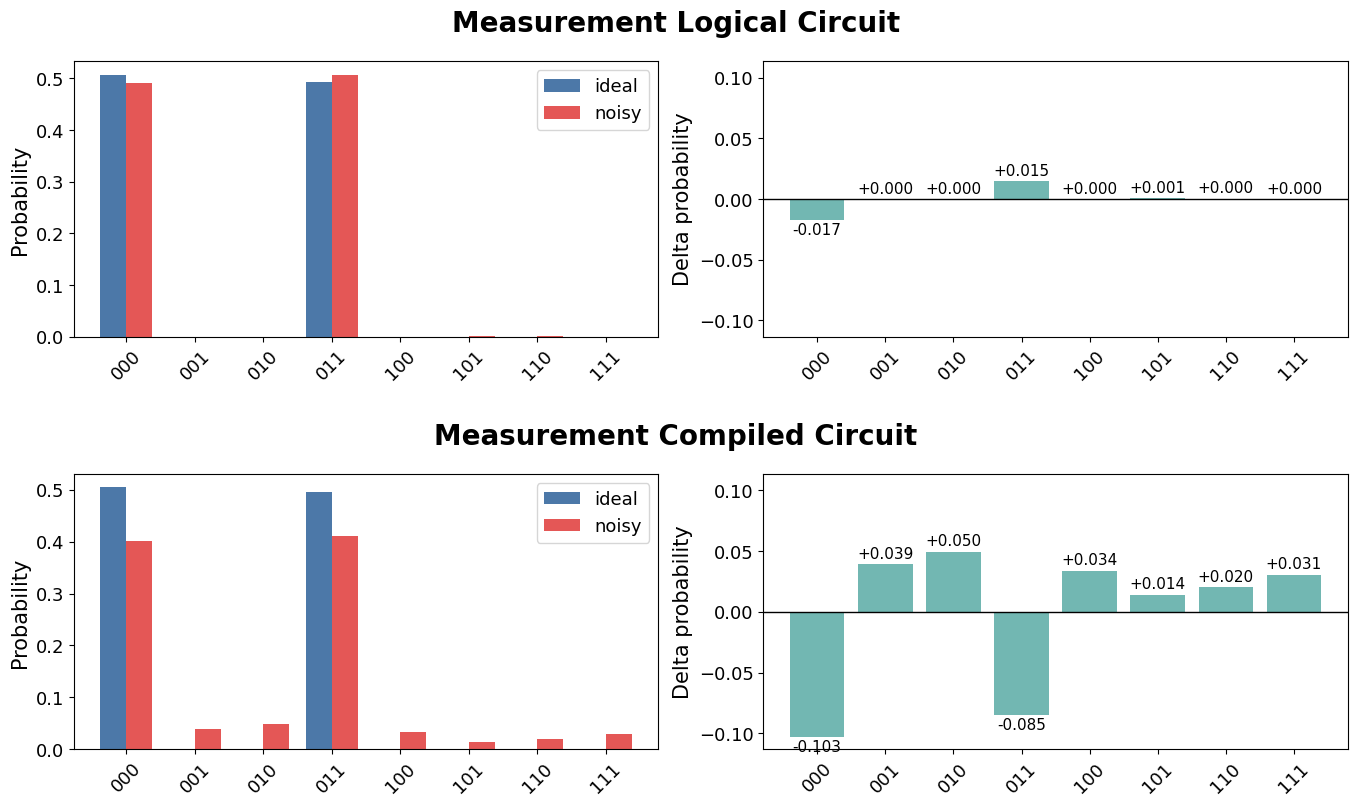

In [ ]:
# Prepare a common x-axis of bitstrings observed in either ideal/noisy runs.
all_states = sorted(
    set(p_ideal_compute) | set(p_noisy_compute) | set(p_ideal_compiled) | set(p_noisy_compiled)
)

ideal_compute_vals = [p_ideal_compute.get(s, 0.0) for s in all_states]
noisy_compute_vals = [p_noisy_compute.get(s, 0.0) for s in all_states]
ideal_compiled_vals = [p_ideal_compiled.get(s, 0.0) for s in all_states]
noisy_compiled_vals = [p_noisy_compiled.get(s, 0.0) for s in all_states]

delta_compute = [n - i for n, i in zip(noisy_compute_vals, ideal_compute_vals)]
delta_compiled = [n - i for n, i in zip(noisy_compiled_vals, ideal_compiled_vals)]

# Force both delta subplots to use the same y-axis range.
delta_all = delta_compute + delta_compiled
delta_abs_max = max(abs(v) for v in delta_all) if delta_all else 0.01
delta_y = max(0.01, 1.1 * delta_abs_max)
label_offset = 0.02 * delta_y
# Extra padding keeps value labels from touching the axis frame.
delta_pad = 2.2 * label_offset

# Typography controls
title_fs = 18
row_title_fs = 20
axis_label_fs = 15
tick_fs = 13
legend_fs = 13
bar_label_fs = 11

x = np.arange(len(all_states))
width = 0.38

# Use manual spacing so we can increase the gap between the two rows.
fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=False)
fig.subplots_adjust(hspace=0.50, wspace=0.18, top=0.93, bottom=0.07, left=0.07, right=0.98)

# Row 1: compute | probability (col 1) and delta (col 2)
axes[0, 0].bar(x - width / 2, ideal_compute_vals, width, label="ideal", color="#4C78A8")
axes[0, 0].bar(x + width / 2, noisy_compute_vals, width, label="noisy", color="#E45756")
axes[0, 0].set_ylabel("Probability", fontsize=axis_label_fs)
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(all_states, rotation=45)
axes[0, 0].tick_params(axis="both", labelsize=tick_fs)
axes[0, 0].legend(fontsize=legend_fs)

bars_compute = axes[0, 1].bar(x, delta_compute, color="#72B7B2")
axes[0, 1].axhline(0, color="black", linewidth=1)
axes[0, 1].set_ylabel("Delta probability", fontsize=axis_label_fs)
axes[0, 1].yaxis.set_label_position("right")
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(all_states, rotation=45)
axes[0, 1].tick_params(axis="both", labelsize=tick_fs)
axes[0, 1].set_ylim(-delta_y - delta_pad, delta_y + delta_pad)

# Row 2: compiled_qc | probability (col 1) and delta (col 2)
axes[1, 0].bar(x - width / 2, ideal_compiled_vals, width, label="ideal", color="#4C78A8")
axes[1, 0].bar(x + width / 2, noisy_compiled_vals, width, label="noisy", color="#E45756")
axes[1, 0].set_ylabel("Probability", fontsize=axis_label_fs)
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(all_states, rotation=45)
axes[1, 0].tick_params(axis="both", labelsize=tick_fs)
axes[1, 0].legend(fontsize=legend_fs)

bars_compiled = axes[1, 1].bar(x, delta_compiled, color="#72B7B2")
axes[1, 1].axhline(0, color="black", linewidth=1)
axes[1, 1].set_ylabel("Delta probability", fontsize=axis_label_fs)
axes[1, 1].yaxis.set_label_position("right")
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(all_states, rotation=45)
axes[1, 1].tick_params(axis="both", labelsize=tick_fs)
axes[1, 1].set_ylim(-delta_y - delta_pad, delta_y + delta_pad)

# Add numeric labels to each delta bar.
for bars, vals, ax in [
    (bars_compute, delta_compute, axes[0, 1]),
    (bars_compiled, delta_compiled, axes[1, 1]),
]:
    for bar, val in zip(bars, vals):
        y = val + (label_offset if val >= 0 else -label_offset)
        va = "bottom" if val >= 0 else "top"
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            y,
            f"{val:+.3f}",
            ha="center",
            va=va,
            fontsize=bar_label_fs,
            rotation=0,
        )

# Place one centered title above each row with extra spacing.
fig.canvas.draw()
row_title_gap = 0.03
top_row_top = max(axes[0, 0].get_position().y1, axes[0, 1].get_position().y1)
bottom_row_top = max(axes[1, 0].get_position().y1, axes[1, 1].get_position().y1)
fig.text(0.5, min(0.995, top_row_top + row_title_gap), "Measurement Logical Circuit", ha="center", va="bottom", fontsize=row_title_fs, fontweight="bold")
fig.text(0.5, min(0.995, bottom_row_top + row_title_gap), "Measurement Compiled Circuit", ha="center", va="bottom", fontsize=row_title_fs, fontweight="bold")

plt.show()